# Steam Game Reviews
## Notebook 01 — Data loading and preprocessing

### Scope

This exploratory notebook loads a bounded 120,000-review sample to document the
cleaning, quality checks and classical TF-IDF preparation workflow. Notebook 00
creates the canonical 120,000-review modelling sample used by the downstream
model notebooks.

### Key assumptions

- Only English reviews with a valid recommendation label are used for text analysis.
- The original review is retained for retrieval and transformer work; `clean_review`
  is the input for classical text features.
- Train and test are grouped by `game_name`, so a game cannot contribute reviews to
  both splits.

## 1. Setup and paths

### 1. Import libraries and set paths

In [1]:
from pathlib import Path
from collections import Counter
import html
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

RANDOM_STATE = 42
N_REVIEW_ROWS = 120_000  # Matches the canonical modelling sample size.

CURRENT_DIR = Path.cwd().resolve()
PROJECT_DIR = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR / "final-project"
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

REVIEWS_PATH = DATA_DIR / "steam_game_reviews.csv"
DESCRIPTIONS_PATH = DATA_DIR / "games_description.csv"
RANKINGS_PATH = DATA_DIR / "games_ranking.csv"

for path in [REVIEWS_PATH, DESCRIPTIONS_PATH, RANKINGS_PATH]:
    assert path.exists(), f"Missing data file: {path}"

print("Project folder:", PROJECT_DIR)
print("Review rows requested:", f"{N_REVIEW_ROWS:,}")

Project folder: /Users/nikitasvaltadoros/Documents/NLP/final-project
Review rows requested: 120,000


## 2. Load and prepare the review sample

### 2. Load the datasets

In [2]:
# The two small tables are loaded completely.
games_description = pd.read_csv(DESCRIPTIONS_PATH)
games_ranking = pd.read_csv(RANKINGS_PATH)

# The review file is about 459 MB, so the analysis uses 120,000 rows.
# Set N_REVIEW_ROWS to None to load the complete file.
reviews = pd.read_csv(REVIEWS_PATH, nrows=N_REVIEW_ROWS, low_memory=False)

print("Games description shape:", games_description.shape)
print("Games ranking shape:", games_ranking.shape)
print("Review sample shape:", reviews.shape)

Games description shape: (290, 13)
Games ranking shape: (672, 4)
Review sample shape: (120000, 8)


### 3. Preview the review data

In [3]:
display(reviews.head(3))
print()
print("Columns:")
print(reviews.columns.tolist())
print()
print("Data types:")
display(reviews.dtypes.to_frame("dtype"))

,review,hours_played,helpful,funny,recommendation,date,game_name,username
0,The game itself is also super fun. The PvP and...,39.9,"1,152",13,Recommended,14 September,"Warhammer 40,000: Space Marine 2",Sentinowl\n224 products in account
1,Never cared much about Warhammer until this ga...,91.5,712,116,Recommended,13 September,"Warhammer 40,000: Space Marine 2",userpig\n248 products in account
2,A salute to all the fallen battle brothers who...,43.3,492,33,Recommended,14 September,"Warhammer 40,000: Space Marine 2",Imparat0r\n112 products in account



Columns:
['review', 'hours_played', 'helpful', 'funny', 'recommendation', 'date', 'game_name', 'username']

Data types:


,dtype
review,object
hours_played,object
helpful,object
funny,object
recommendation,object
date,object
game_name,object
username,object


### 4. Check missing values and duplicates

In [4]:
quality_check = pd.DataFrame({
    "missing_values": reviews.isna().sum(),
    "missing_percent": reviews.isna().mean().mul(100),
    "unique_values": reviews.nunique(dropna=True),
})
display(quality_check.round(2))

print("Completely duplicated rows:", reviews.duplicated().sum())
print("Duplicated review texts:", reviews["review"].duplicated().sum())

,missing_values,missing_percent,unique_values
review,44,0.04,114041
hours_played,0,0.00,22341
helpful,0,0.00,1712
funny,0,0.00,992
recommendation,0,0.00,2
date,0,0.00,4246
game_name,0,0.00,27
username,12,0.01,110209


Completely duplicated rows: 0
Duplicated review texts: 5958


### 5. Keep the fields required for the analysis

The original review is retained for later transformer and retrieval steps. The cleaned review is used for the classical text features. The date, play time, and review length are kept as additional metadata.

In [5]:
review_data = reviews[
    ["game_name", "recommendation", "review", "hours_played", "date"]
].copy()

# Remove rows that cannot be used for text classification.
review_data = review_data.dropna(subset=["review", "recommendation"])
review_data = review_data.loc[review_data["review"].str.strip().ne("")]
review_data = review_data.drop_duplicates(subset=["review", "recommendation", "game_name"])

review_data["target"] = review_data["recommendation"].map({
    "Not Recommended": 0,
    "Recommended": 1,
})
review_data = review_data.dropna(subset=["target"]).reset_index(drop=True)
review_data["target"] = review_data["target"].astype(int)

print("Rows remaining:", f"{len(review_data):,}")
display(review_data.head(3))

Rows remaining: 116,601


,game_name,recommendation,review,hours_played,date,target
0,"Warhammer 40,000: Space Marine 2",Recommended,The game itself is also super fun. The PvP and...,39.9,14 September,1
1,"Warhammer 40,000: Space Marine 2",Recommended,Never cared much about Warhammer until this ga...,91.5,13 September,1
2,"Warhammer 40,000: Space Marine 2",Recommended,A salute to all the fallen battle brothers who...,43.3,14 September,1


### 6. Keep English reviews

The text models use English reviews. Language is detected before text normalization so the original review remains available.

In [6]:
try:
    from langdetect import DetectorFactory, detect
    from langdetect.lang_detect_exception import LangDetectException

    DetectorFactory.seed = RANDOM_STATE

    def detect_language(text):
        try:
            return detect(str(text))
        except LangDetectException:
            return "unknown"

    language_method = "langdetect"
except ImportError:
    # A small fallback keeps the notebook runnable without an extra package.
    english_markers = {
        "the", "and", "to", "of", "a", "in", "is", "it", "this", "that",
        "game", "play", "with", "for", "not", "good", "great", "bad",
    }

    def detect_language(text):
        words = re.findall(r"[a-zA-Z]+", str(text).lower())
        if len(words) < 3:
            return "unknown"
        marker_ratio = sum(word in english_markers for word in words) / len(words)
        return "en" if marker_ratio >= 0.02 else "unknown"

    language_method = "English-word fallback"

review_data["language"] = review_data["review"].map(detect_language)
language_summary = review_data["language"].value_counts().to_frame("reviews")
display(language_summary.head(10))

review_data = review_data.loc[review_data["language"].eq("en")].reset_index(drop=True)
print("Language method:", language_method)
print("English reviews retained:", f"{len(review_data):,}")

,reviews
language,
en,100339
unknown,1676
so,1463
de,1154
af,1069
no,844
tl,803
da,684
cy,632


Language method: langdetect
English reviews retained: 100,339


### 7. Inspect the target-label balance

,reviews,percent
recommendation,,
Recommended,64948,64.73
Not Recommended,35391,35.27


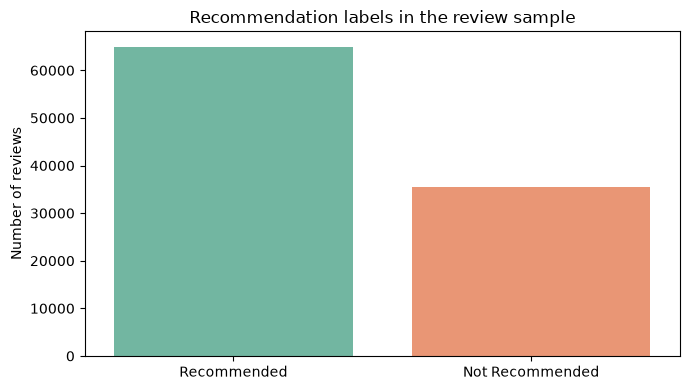

In [7]:
label_summary = review_data["recommendation"].value_counts().to_frame("reviews")
label_summary["percent"] = label_summary["reviews"].div(len(review_data)).mul(100)
display(label_summary.round(2))

plt.figure(figsize=(7, 4))
sns.countplot(data=review_data, x="recommendation", hue="recommendation", palette="Set2", legend=False)
plt.title("Recommendation labels in the review sample")
plt.xlabel("")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

### 8. Inspect review lengths

,review_length_characters,review_length_words
count,100339.0,100339.0
mean,526.0,94.2
std,1000.0,177.1
min,1.0,1.0
25%,59.0,11.0
50%,159.0,29.0
75%,515.0,93.0
95%,2303.1,408.0
99%,5534.6,982.6
max,8271.0,1658.0


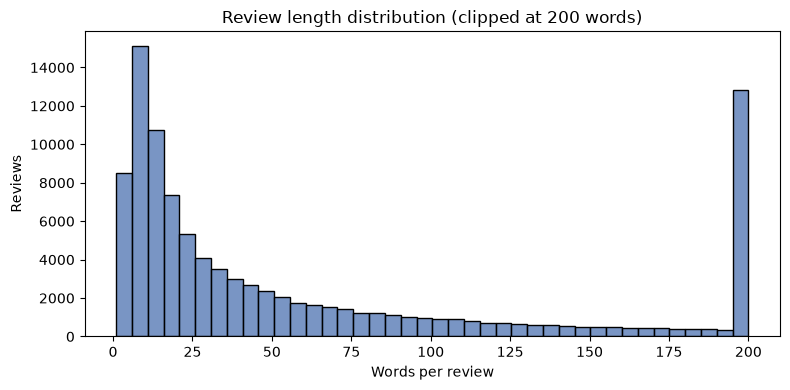

In [8]:
review_data["review_length_characters"] = review_data["review"].str.len()
review_data["review_length_words"] = review_data["review"].str.split().str.len()

display(
    review_data[["review_length_characters", "review_length_words"]]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99])
    .round(1)
)

plt.figure(figsize=(8, 4))
sns.histplot(review_data["review_length_words"].clip(upper=200), bins=40, color="#4C72B0")
plt.title("Review length distribution (clipped at 200 words)")
plt.xlabel("Words per review")
plt.ylabel("Reviews")
plt.tight_layout()
plt.show()

### 9. Define the text preprocessing function

The function lowercases the text, replaces URLs and usernames, removes HTML, emojis, and special characters, normalizes repeated letters, removes very short words, and removes stopwords while preserving negation words.

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

try:
    import nltk
    from nltk.corpus import stopwords

    NLTK_DATA_DIR = PROJECT_DIR.parent / "nltk_data"
    if str(NLTK_DATA_DIR) not in nltk.data.path:
        nltk.data.path.insert(0, str(NLTK_DATA_DIR))
    stopword_list = set(stopwords.words("english"))
    stopword_source = "NLTK"
except (ImportError, LookupError):
    stopword_list = set(ENGLISH_STOP_WORDS)
    stopword_source = "scikit-learn fallback"

NEGATIONS = {"no", "not", "nor", "never"}
CUSTOM_STOPWORDS = stopword_list - NEGATIONS

URL_PATTERN = re.compile(r"(?:https?|ftp)://\S+|www\.\S+", flags=re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\b[\w.\-+]+@[\w.\-]+\.\w+\b")
USERNAME_PATTERN = re.compile(r"(?<!\w)@\w+")
HTML_PATTERN = re.compile(r"<[^>]+>")
EMOJI_PATTERN = re.compile("[\U0001F300-\U0001FAFF\U00002700-\U000027BF]+", flags=re.UNICODE)
REPEATED_LETTER_PATTERN = re.compile(r"(\w)\1{2,}")

def preprocess_text(text):
    text = html.unescape(str(text)).lower()
    text = URL_PATTERN.sub(" url ", text)
    text = EMAIL_PATTERN.sub(" user ", text)
    text = USERNAME_PATTERN.sub(" user ", text)
    text = HTML_PATTERN.sub(" ", text)
    text = EMOJI_PATTERN.sub(" ", text)
    text = REPEATED_LETTER_PATTERN.sub(r"\1\1", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = re.sub(r"\s+", " ", text).strip().split()
    words = [word for word in words if len(word) >= 3 or word in NEGATIONS]
    words = [word for word in words if word not in CUSTOM_STOPWORDS]
    return " ".join(words)

print("Stopword source:", stopword_source)

Stopword source: NLTK


### 10. Apply preprocessing and compare examples

In [10]:
review_data["clean_review"] = review_data["review"].map(preprocess_text)
review_data = review_data.loc[review_data["clean_review"].str.len().gt(0)].reset_index(drop=True)

example_comparison = review_data[["review", "clean_review", "recommendation"]].sample(
    8, random_state=RANDOM_STATE
)
display(example_comparison)

,review,clean_review,recommendation
51344,2018 Lobby Simulator 2016-currentHigh rank the...,lobby simulator currenthigh rank killers meet ...,Not Recommended
73772,2022 Super fun little roguelike with systemic ...,super fun little roguelike systemic game desig...,Recommended
73094,Hilariously complex and absolutely unique. You...,hilariously complex absolutely unique die lot ...,Recommended
52432,2021 one of the worst mmr ive ever seen rank 2...,one worst mmr ive ever seen rank play rank hou...,Not Recommended
52869,Wake up every morning with a fat cup of JUICE....,wake every morning fat cup juice remaster grea...,Recommended
20160,"2021 Much hate with no reason, this game is fu...",much hate no reason game fun,Recommended
50996,2022 The worst love-hate relationship you'll e...,worst love hate relationship ever experience p...,Not Recommended
43192,"2022 Every time this piece of ♥♥♥♥ crashes, wh...",every time piece crashes often must optomize s...,Not Recommended


### 11. Show the most frequent cleaned words

,word,frequency
0,game,190989
1,not,56151
2,like,44776
3,play,37236
4,get,35043
5,good,30362
6,time,28629
7,fun,28233
8,one,26465
9,no,26321


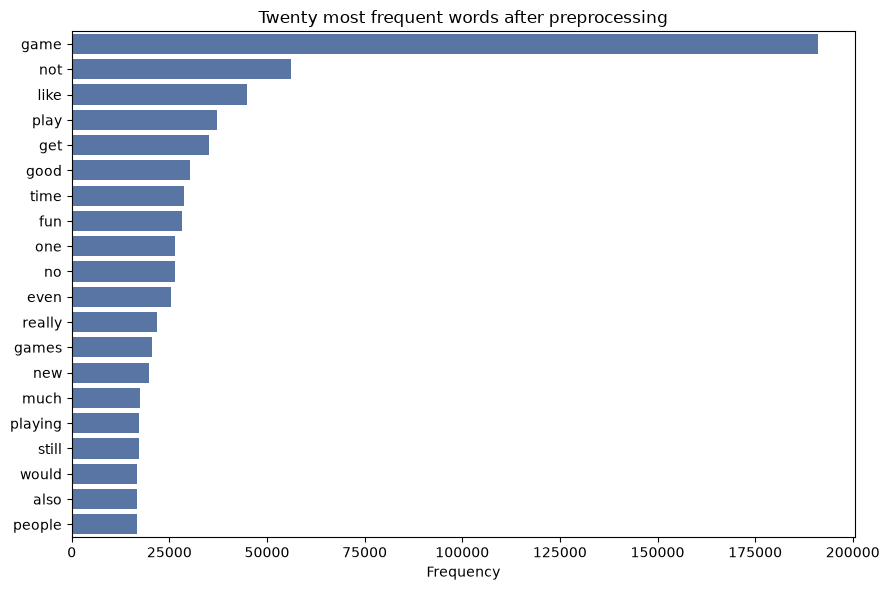

In [11]:
word_counts = Counter(
    word
    for text in review_data["clean_review"]
    for word in text.split()
)
most_common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "frequency"],
)
display(most_common_words)

plt.figure(figsize=(9, 6))
sns.barplot(data=most_common_words, x="frequency", y="word", color="#4C72B0")
plt.title("Twenty most frequent words after preprocessing")
plt.xlabel("Frequency")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 12. Create a game-grouped train/test split

All reviews for a game are assigned to one split only. This prevents the classifier
from benefiting from game-specific language already seen during training.

In [12]:
from sklearn.model_selection import GroupShuffleSplit

game_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(
    game_splitter.split(review_data, review_data["target"], groups=review_data["game_name"])
)

train_data = review_data.iloc[train_idx]
test_data = review_data.iloc[test_idx]
X_train, X_test = train_data["clean_review"], test_data["clean_review"]
y_train, y_test = train_data["target"], test_data["target"]

train_games = set(train_data["game_name"])
test_games = set(test_data["game_name"])
assert not train_games & test_games, "A game appears in both splits."

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "games": [len(train_games), len(test_games)],
    "recommended_percent": [y_train.mean() * 100, y_test.mean() * 100],
}, index=["training", "testing"])
display(split_summary.round(2))

,rows,games,recommended_percent
training,78236,21,67.20
testing,21939,6,55.85


### 13. Create TF-IDF features

These matrices provide a baseline text representation for traditional classification models such as Logistic Regression, Random Forest, or XGBoost.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=384,
    min_df=5,
    max_df=0.8,
    # Stopwords were removed above while negation words were preserved.
    stop_words=None,
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Example feature names:", tfidf_vectorizer.get_feature_names_out()[:20].tolist())

Training TF-IDF shape: (78236, 384)
Testing TF-IDF shape: (21939, 384)
Example feature names: ['able', 'absolutely', 'access', 'actually', 'add', 'added', 'almost', 'already', 'also', 'always', 'amazing', 'amount', 'annoying', 'another', 'anymore', 'anyone', 'anything', 'around', 'attack', 'away']


### 14. Check the feature limit

The following check shows how many terms are available at a few feature limits. The final limit can be selected after the classifier experiments.

In [14]:
feature_size_check = []
for feature_limit in [384, 768, 1024]:
    candidate_vectorizer = TfidfVectorizer(
        max_features=feature_limit,
        min_df=5,
        max_df=0.8,
        stop_words=None,
    )
    candidate_matrix = candidate_vectorizer.fit_transform(X_train)
    feature_size_check.append({
        "max_features": feature_limit,
        "features_available": candidate_matrix.shape[1],
    })

display(pd.DataFrame(feature_size_check))

,max_features,features_available
0,384,384
1,768,768
2,1024,1024


## Checks and artifacts

### 15. Verify and save the prepared sample

In [15]:
assert review_data["review"].notna().all()
assert review_data["recommendation"].isin(["Recommended", "Not Recommended"]).all()
assert review_data["clean_review"].str.len().gt(0).all()
assert X_train_tfidf.shape[1] == X_test_tfidf.shape[1]
assert review_data["language"].eq("en").all()
assert not train_games & test_games

prepared_path = OUTPUT_DIR / "prepared_reviews_sample.csv"
prepared_columns = [
    "game_name", "recommendation", "target", "review", "clean_review",
    "review_length_words", "hours_played", "date", "language",
]
review_data[prepared_columns].to_csv(prepared_path, index=False)

print("All checks passed.")
print("Prepared sample saved to:", prepared_path)

All checks passed.
Prepared sample saved to: /Users/nikitasvaltadoros/Documents/NLP/final-project/outputs/prepared_reviews_sample.csv
